# 08 — Experimentos de la comparativa

Ejecuta el diseño experimental definido en el Capítulo 4 sobre el conjunto de prueba
(temporadas 2023-24 y 2024-25).


In [1]:
import sys, warnings, time
from pathlib import Path
sys.path.insert(0, "../src")
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import log_loss

from tfm_segunda.metrics import (LABELS, brier_multiclase, rps, ece,
                                 reliability_data, evaluar_ampliado)
from tfm_segunda.predictions import MODELOS_TODOS, MODELOS_SKLEARN, cols_proba, slug_de
from tfm_segunda import economics as eco

sns.set_theme(style="whitegrid", font_scale=0.9)
RNG = np.random.default_rng(42)

REPORTS = Path("../reports"); TABLES = REPORTS / "tables"; FIGURES = REPORTS / "figures"
TABLES.mkdir(parents=True, exist_ok=True); FIGURES.mkdir(parents=True, exist_ok=True)

test = pd.read_parquet(REPORTS / "predictions_test.parquet")
val  = pd.read_parquet(REPORTS / "predictions_validation.parquet")
y_test, y_val = test["ftr"].values, val["ftr"].values

COLS_MERCADO = ["mercado__pA", "mercado__pD", "mercado__pH"]
def P(df, modelo):
    return df[cols_proba(modelo)].values
def P_mercado(df):
    return df[COLS_MERCADO].values

print(f"test: {len(test)} partidos | validación: {len(val)} | modelos: {len(MODELOS_TODOS)}")

test: 901 partidos | validación: 1338 | modelos: 10


## 1. Tabla maestra de métricas

Todas las métricas  para los once modelos y la línea base de mercado.

In [2]:
df_full = pd.read_parquet("data/processed/dataset_modelado.parquet")
META = ["split","season","date","jornada","home_team","away_team","fthg","ftag"]
FEATS = [c for c in df_full.columns if c not in META + ["ftr"]]
tr = df_full[df_full.split == "train"].dropna(subset=FEATS)
X_tr, y_tr = tr[FEATS], tr["ftr"].values
y_tr_enc = pd.Series(y_tr).map({"A":0,"D":1,"H":2}).values

from sklearn.base import clone
from sklearn.preprocessing import StandardScaler
scaler_t = StandardScaler().fit(X_tr.astype(float))

tiempos = {}
for nombre, (fichero, escala) in MODELOS_SKLEARN.items():
    mdl = clone(joblib.load(Path("models") / fichero))
    Xf = scaler_t.transform(X_tr.astype(float)) if escala else X_tr.values
    yf = y_tr if isinstance(joblib.load(Path("models") / fichero).classes_[0], str) else y_tr_enc
    t0 = time.time(); mdl.fit(Xf, yf); tiempos[nombre] = time.time() - t0
    print(f"{nombre:26s} {tiempos[nombre]:7.2f} s")

LogReg sin pesos              0.01 s
LogReg balanced               0.01 s


Random Forest sin pesos       0.28 s


Random Forest balanced        0.66 s


XGBoost sin pesos             0.20 s


XGBoost balanced              0.35 s


LightGBM sin pesos            0.23 s
LightGBM balanced             0.15 s


MLP                           0.20 s


In [3]:
filas = []
for m in MODELOS_TODOS:
    filas.append(evaluar_ampliado(y_test, P(test, m), m, tiempos.get(m)))
filas.append(evaluar_ampliado(y_test, P_mercado(test), "Mercado (sin margen)"))
tabla_maestra = pd.DataFrame(filas).sort_values("log_loss").reset_index(drop=True)
tabla_maestra.to_csv(TABLES / "t01_tabla_maestra.csv", index=False)
tabla_maestra.round(4)

,modelo,log_loss,brier,rps,ece,accuracy,f1_macro,f1_A,f1_D,f1_H,t_train_s
0,Mercado (sin margen),1.0292,0.6188,0.2062,0.0251,0.4861,0.3339,0.3407,0.0222,0.6387,NaN
1,XGBoost sin pesos,1.0296,0.6189,0.2067,0.0256,0.4928,0.3648,0.2848,0.1682,0.6414,0.2034
2,LogReg sin pesos,1.0312,0.6203,0.2071,0.0303,0.4739,0.3084,0.1871,0.1022,0.6358,0.0114
3,LightGBM sin pesos,1.0313,0.6204,0.2072,0.0223,0.4850,0.3168,0.2689,0.0438,0.6378,0.2263
4,Doble Poisson,1.0339,0.6212,0.2069,0.0135,0.4861,0.3341,0.3613,0.0000,0.6410,NaN
5,Random Forest sin pesos,1.0350,0.6228,0.2084,0.0227,0.4639,0.2673,0.1612,0.0148,0.6259,0.2823
6,MLP,1.0533,0.6366,0.2124,0.0213,0.4584,0.3028,0.1625,0.1166,0.6293,0.2007
7,LightGBM balanced,1.0679,0.6438,0.2185,0.0375,0.4195,0.3989,0.4043,0.2789,0.5135,0.1481
8,LogReg balanced,1.0706,0.6462,0.2198,0.0262,0.4284,0.3925,0.4033,0.2314,0.5430,0.0054
9,Random Forest balanced,1.0717,0.6469,0.2199,0.0393,0.4206,0.3963,0.3993,0.2628,0.5269,0.6647


## 2. Calibración

Regresión isotónica por clase ajustada en validación y aplicada al test (con
renormalización). Se reporta el efecto sobre cada métrica y los reliability diagrams
de la clase H antes y después.

In [4]:
from sklearn.isotonic import IsotonicRegression

def calibrar(modelo):
    Pv, Pt = P(val, modelo), P(test, modelo)
    Pc = np.empty_like(Pt)
    for j, c in enumerate(LABELS):
        iso = IsotonicRegression(out_of_bounds="clip", y_min=1e-6, y_max=1-1e-6)
        iso.fit(Pv[:, j], (y_val == c).astype(float))
        Pc[:, j] = iso.predict(Pt[:, j])
    return Pc / Pc.sum(axis=1, keepdims=True)

P_cal = {m: calibrar(m) for m in MODELOS_TODOS}

filas = []
for m in MODELOS_TODOS:
    antes = evaluar_ampliado(y_test, P(test, m), m)
    desp  = evaluar_ampliado(y_test, P_cal[m], m)
    filas.append({"modelo": m,
                  "log_loss": antes["log_loss"], "log_loss_cal": desp["log_loss"],
                  "brier": antes["brier"], "brier_cal": desp["brier"],
                  "rps": antes["rps"], "rps_cal": desp["rps"],
                  "ece": antes["ece"], "ece_cal": desp["ece"]})
tabla_cal = pd.DataFrame(filas).sort_values("log_loss_cal")
tabla_cal.to_csv(TABLES / "t02_calibracion.csv", index=False)
tabla_cal.round(4)

,modelo,log_loss,log_loss_cal,brier,brier_cal,rps,rps_cal,ece,ece_cal
1,LogReg balanced,1.0706,1.0268,0.6462,0.6176,0.2198,0.2062,0.0262,0.0280
0,LogReg sin pesos,1.0312,1.0295,0.6203,0.6190,0.2071,0.2068,0.0303,0.0530
5,XGBoost balanced,1.0720,1.0328,0.6465,0.6205,0.2192,0.2070,0.0311,0.0219
3,Random Forest balanced,1.0717,1.0382,0.6469,0.6230,0.2199,0.2083,0.0393,0.0200
9,Doble Poisson,1.0339,1.0414,0.6212,0.6197,0.2069,0.2066,0.0135,0.0319
2,Random Forest sin pesos,1.0350,1.0461,0.6228,0.6234,0.2084,0.2086,0.0227,0.0356
4,XGBoost sin pesos,1.0296,1.0531,0.6189,0.6194,0.2067,0.2070,0.0256,0.0428
7,LightGBM balanced,1.0679,1.0547,0.6438,0.6193,0.2185,0.2065,0.0375,0.0219
6,LightGBM sin pesos,1.0313,1.0656,0.6204,0.6218,0.2072,0.2073,0.0223,0.0212
8,MLP,1.0533,1.0688,0.6366,0.6387,0.2124,0.2136,0.0213,0.0237


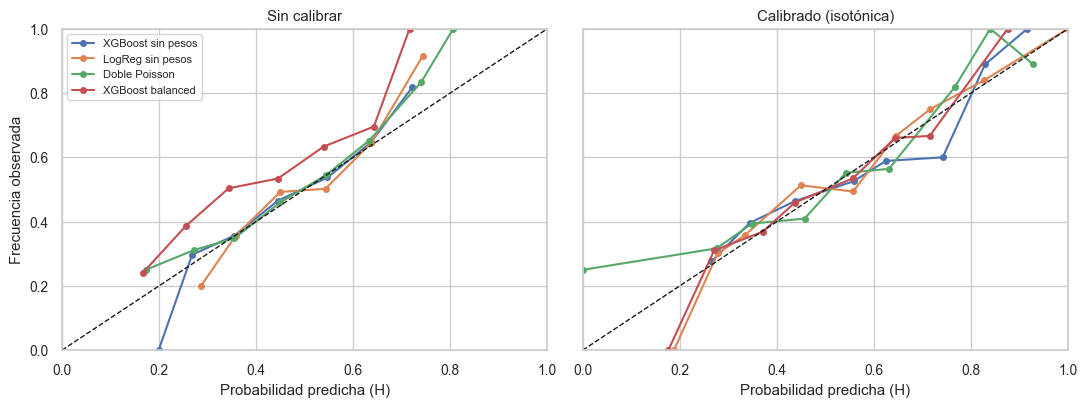

In [5]:
SELECCION = ["XGBoost sin pesos", "LogReg sin pesos", "Doble Poisson", "XGBoost balanced"]
fig, axes = plt.subplots(1, 2, figsize=(11, 4.2), sharey=True)
for ax, (probs, titulo) in zip(axes, [({m: P(test, m) for m in SELECCION}, "Sin calibrar"),
                                       ({m: P_cal[m] for m in SELECCION}, "Calibrado (isotónica)")]):
    for m, Pm in probs.items():
        d = reliability_data(y_test, Pm, clase="H")
        ax.plot(d.p_media, d.frec_obs, "o-", label=m, ms=4)
    ax.plot([0,1],[0,1],"k--",lw=1); ax.set_title(titulo)
    ax.set_xlabel("Probabilidad predicha (H)"); ax.set_xlim(0,1); ax.set_ylim(0,1)
axes[0].set_ylabel("Frecuencia observada"); axes[0].legend(fontsize=8)
plt.tight_layout(); plt.savefig(FIGURES / "f02_reliability_H.png", dpi=150); plt.show()

## 3. ¿Existe un modelo globalmente mejor? Criterio estadístico

Bootstrap pareado (10.000 remuestreos) de la diferencia de log-loss y RPS entre pares de
modelos: si el intervalo de confianza del 95 % contiene el 0, la diferencia no es
significativa. Test exacto de McNemar sobre los aciertos de la clase predicha.

In [ ]:
from scipy.stats import binomtest

def bootstrap_diff(PA, PB, y, metrica, B=10_000):
    n = len(y); idx = RNG.integers(0, n, size=(B, n))
    Y = np.column_stack([(y == c).astype(float) for c in LABELS])
    if metrica == "log_loss":
        per = lambda Pm: -np.sum(Y * np.log(np.clip(Pm, 1e-15, 1)), axis=1)
    else:
        def per(Pm):
            cp, cy = np.cumsum(Pm, axis=1)[:, :-1], np.cumsum(Y, axis=1)[:, :-1]
            return np.sum((cp - cy) ** 2, axis=1) / 2
    dif = per(PA) - per(PB)
    medias = dif[idx].mean(axis=1)
    lo, hi = np.percentile(medias, [2.5, 97.5])
    return dif.mean(), lo, hi

def mcnemar(PA, PB, y):
    accA = np.array(LABELS)[PA.argmax(1)] == y
    accB = np.array(LABELS)[PB.argmax(1)] == y
    b, c = int((accA & ~accB).sum()), int((~accA & accB).sum())
    p = binomtest(min(b, c), b + c, 0.5).pvalue if b + c else 1.0
    return b, c, p

REF = [("XGBoost sin pesos", "Mercado"), ("LogReg sin pesos", "Mercado"),
       ("Doble Poisson", "Mercado"), ("XGBoost sin pesos", "LogReg sin pesos"),
       ("XGBoost sin pesos", "Doble Poisson"), ("XGBoost sin pesos", "XGBoost balanced")]
get = lambda m: P_mercado(test) if m == "Mercado" else P(test, m)

filas = []
for a, b in REF:
    dll, lo1, hi1 = bootstrap_diff(get(a), get(b), y_test, "log_loss")
    drp, lo2, hi2 = bootstrap_diff(get(a), get(b), y_test, "rps")
    nb, nc, pmc = mcnemar(get(a), get(b), y_test)
    filas.append({"A": a, "B": b, "d_logloss": dll, "ll_IC95": f"[{lo1:+.4f}, {hi1:+.4f}]",
                  "ll_signif": not (lo1 <= 0 <= hi1), "d_rps": drp,
                  "rps_IC95": f"[{lo2:+.4f}, {hi2:+.4f}]", "rps_signif": not (lo2 <= 0 <= hi2),
                  "mcnemar_p": pmc})
tabla_stats = pd.DataFrame(filas)
tabla_stats.to_csv(TABLES / "t03_tests_estadisticos.csv", index=False)
tabla_stats.round(4)

,A,B,d_logloss,ll_IC95,ll_signif,d_rps,rps_IC95,rps_signif,mcnemar_p
0,XGBoost sin pesos,Mercado,0.0004,"[-0.0074, +0.0084]",False,0.0004,"[-0.0015, +0.0025]",False,0.5666
1,LogReg sin pesos,Mercado,0.0020,"[-0.0056, +0.0095]",False,0.0008,"[-0.0014, +0.0031]",False,0.2723
2,Doble Poisson,Mercado,0.0048,"[-0.0027, +0.0122]",False,0.0007,"[-0.0011, +0.0024]",False,1.0000
3,XGBoost sin pesos,LogReg sin pesos,-0.0016,"[-0.0074, +0.0041]",False,-0.0004,"[-0.0020, +0.0012]",False,0.0498
4,XGBoost sin pesos,Doble Poisson,-0.0044,"[-0.0135, +0.0047]",False,-0.0003,"[-0.0023, +0.0018]",False,0.5900
5,XGBoost sin pesos,XGBoost balanced,-0.0424,"[-0.0595, -0.0258]",True,-0.0125,"[-0.0177, -0.0073]",True,0.0000


## 4. Marco de evaluación por situaciones

Log-loss por segmento: favoritismo del mercado (terciles de `match_uncertainty`),
implicación en zona decisiva (algún equipo en puestos 1-6 o 17-22 antes del partido),
fase de la temporada y resultado real. Modelos representativos + mercado.

In [7]:
ctx = df_full[df_full.split == "test"].dropna(subset=FEATS)[
    ["season","date","home_team","away_team","jornada","match_uncertainty",
     "home_pos_pre","away_pos_pre"]]
seg = test.merge(ctx, on=["season","date","home_team","away_team","jornada"],
                 how="left", validate="one_to_one")
assert len(seg) == len(test)

terc = seg.match_uncertainty.quantile([1/3, 2/3]).values
seg["favoritismo"] = np.select(
    [seg.match_uncertainty <= terc[0], seg.match_uncertainty <= terc[1]],
    ["favorito claro", "intermedio"], default="partido incierto")
en_zona = lambda p: (p <= 6) | (p >= 17)
seg["zona"] = np.where(en_zona(seg.home_pos_pre) | en_zona(seg.away_pos_pre),
                       "decisivo (asc/desc)", "media tabla")
seg["fase"] = pd.cut(seg.jornada, [0, 14, 28, 50],
                     labels=["inicio (j1-14)", "medio (j15-28)", "final (j29-42)"])
seg["resultado"] = seg.ftr.map({"H": "victoria local", "D": "empate", "A": "victoria visitante"})

MOD_SEG = ["XGBoost sin pesos", "LogReg sin pesos", "Doble Poisson",
           "XGBoost balanced", "Mercado"]
filas = []
for dim in ["favoritismo", "zona", "fase", "resultado"]:
    for valor, g in seg.groupby(dim, observed=True):
        if g[dim].isna().all(): continue
        fila = {"dimension": dim, "segmento": str(valor), "n": len(g)}
        for m in MOD_SEG:
            Pm = P_mercado(g) if m == "Mercado" else P(g, m)
            fila[m] = log_loss(g.ftr, Pm, labels=LABELS)
        filas.append(fila)
tabla_situaciones = pd.DataFrame(filas)
tabla_situaciones.to_csv(TABLES / "t04_situaciones.csv", index=False)
tabla_situaciones.round(4)

,dimension,segmento,n,XGBoost sin pesos,LogReg sin pesos,Doble Poisson,XGBoost balanced,Mercado
0,favoritismo,favorito claro,302,0.9567,0.9483,0.9480,0.9964,0.9471
1,favoritismo,intermedio,299,1.0634,1.0695,1.0708,1.1017,1.0611
2,favoritismo,partido incierto,300,1.0691,1.0765,1.0837,1.1184,1.0800
3,zona,decisivo (asc/desc),733,1.0238,1.0251,1.0261,1.0652,1.0218
4,zona,media tabla,168,1.0549,1.0579,1.0680,1.1012,1.0612
5,fase,inicio (j1-14),280,1.0362,1.0414,1.0273,1.0660,1.0316
6,fase,medio (j15-28),311,1.0603,1.0546,1.0781,1.0995,1.0597
7,fase,final (j29-42),310,0.9927,0.9985,0.9957,1.0496,0.9964
8,resultado,victoria local,419,0.7595,0.7557,0.7573,1.0479,0.7982
9,resultado,empate,264,1.2266,1.2356,1.3550,1.1258,1.2332


## 5. Valor económico esperado por equipo
Con los supuestos económicos del módulo `economics` (V_ascenso, V_descenso —
editables y documentados como supuestos), se convierte cada Montecarlo de temporada
completa en euros esperados por equipo y se mide el error económico de cada modelo
frente al desenlace real.

In [ ]:
MC_FULL = Path("data/simulations")
print(f"Supuestos: V_ascenso = {eco.VALOR_ASCENSO_EUR/1e6:.0f} M EUR | "
      f"V_descenso = {eco.VALOR_DESCENSO_EUR/1e6:.0f} M EUR")

def ev_real(df_mc):
    v = np.zeros(len(df_mc))
    v[df_mc.pos_real <= 2] = eco.VALOR_ASCENSO_EUR
    v[df_mc.pos_real >= 19] = -eco.VALOR_DESCENSO_EUR
    return v

filas = []
for m in MODELOS_TODOS:
    errores = []
    for season, asc_po in [(2023, "Espanyol"), (2024, "Oviedo")]:
        f = MC_FULL / f"montecarlo_{slug_de(m)}_t{season}.csv"
        mc = pd.read_csv(f)
        ev = eco.valor_esperado_equipo(mc.set_index("equipo")).values
        real = ev_real(mc)
        real[mc.equipo.eq(asc_po)] = eco.VALOR_ASCENSO_EUR
        errores.append(np.abs(ev - real))
    err = np.concatenate(errores)
    filas.append({"modelo": m, "error_economico_medio_MEUR": err.mean()/1e6,
                  "error_economico_max_MEUR": err.max()/1e6})
tabla_ev = pd.DataFrame(filas).sort_values("error_economico_medio_MEUR")
tabla_ev.to_csv(TABLES / "t05_error_economico.csv", index=False)
tabla_ev.round(2)

Supuestos: V_ascenso = 42 M EUR | V_descenso = 1 M EUR


,modelo,error_economico_medio_MEUR,error_economico_max_MEUR
5,XGBoost balanced,6.30,29.48
4,XGBoost sin pesos,6.33,28.65
3,Random Forest balanced,6.35,28.05
2,Random Forest sin pesos,6.51,27.67
7,LightGBM balanced,6.63,29.38
0,LogReg sin pesos,6.81,28.48
6,LightGBM sin pesos,6.89,29.78
1,LogReg balanced,6.95,29.20
9,Doble Poisson,7.00,32.46
8,MLP,7.25,31.91


## 6. Pérdida Económica Esperada (métrica propia)

PEE = log-loss ponderado por el dinero que cada partido pone en juego (pesos comunes a
todos los modelos, derivados del Montecarlo a cortes del modelo de referencia y
normalizados a media 1). PEE > log-loss ⟹ el modelo falla más donde hay dinero en juego.

In [9]:
pesos = eco.pesos_economicos(test)
test["peso_eur"] = pesos

filas = []
for m in MODELOS_TODOS:
    ll = log_loss(y_test, P(test, m), labels=LABELS)
    p_ = eco.pee(y_test, P(test, m), pesos)
    filas.append({"modelo": m, "log_loss": ll, "PEE": p_, "delta": p_ - ll})
ll_m = log_loss(y_test, P_mercado(test), labels=LABELS)
pee_m = eco.pee(y_test, P_mercado(test), pesos)
filas.append({"modelo": "Mercado (sin margen)", "log_loss": ll_m, "PEE": pee_m,
              "delta": pee_m - ll_m})
tabla_pee = pd.DataFrame(filas).sort_values("PEE").reset_index(drop=True)
tabla_pee["rank_PEE"] = tabla_pee.index + 1
tabla_pee["rank_logloss"] = tabla_pee.log_loss.rank().astype(int)
tabla_pee.to_csv(TABLES / "t06_pee.csv", index=False)
tabla_pee.round(4)

,modelo,log_loss,PEE,delta,rank_PEE,rank_logloss
0,Mercado (sin margen),1.0292,1.0204,-0.0088,1,1
1,XGBoost sin pesos,1.0296,1.0210,-0.0085,2,2
2,LogReg sin pesos,1.0312,1.0216,-0.0096,3,3
3,LightGBM sin pesos,1.0313,1.0228,-0.0086,4,4
4,Random Forest sin pesos,1.0350,1.0256,-0.0094,5,6
5,Doble Poisson,1.0339,1.0267,-0.0072,6,5
6,MLP,1.0533,1.0406,-0.0128,7,7
7,LightGBM balanced,1.0679,1.0658,-0.0021,8,8
8,Random Forest balanced,1.0717,1.0701,-0.0015,9,10
9,LogReg balanced,1.0706,1.0704,-0.0001,10,9


In [10]:
top_pesos = test.nlargest(10, "peso_eur")[
    ["season","jornada","home_team","away_team","ftr","peso_eur"]].copy()
top_pesos["peso_MEUR"] = (top_pesos.pop("peso_eur")/1e6).round(1)
top_pesos.to_csv(TABLES / "t06b_partidos_mas_dinero.csv", index=False)
top_pesos

,season,jornada,home_team,away_team,ftr,peso_MEUR
410,2023,39,Valladolid,Espanyol,D,83.8
755,2024,29,Racing,Elche,H,83.4
734,2024,27,Almeria,Elche,D,83.3
533,2024,9,Racing,Levante,H,83.2
131,2023,14,Espanyol,Eibar,D,82.0
783,2024,32,Mirandes,Racing,H,81.8
335,2023,32,Valladolid,Eibar,H,81.4
109,2023,12,Espanyol,Leganes,A,81.3
120,2023,13,Eibar,Valladolid,H,81.3
287,2023,28,Eibar,Espanyol,A,80.7


## 7. Resolución de la incertidumbre económica

Evolución del valor económico esperado de cada equipo a medida que avanza la liga
(Montecarlo a cortes, modelo de referencia). El estrechamiento del embudo muestra
cuándo deja de estar abierta la temporada en términos económicos.

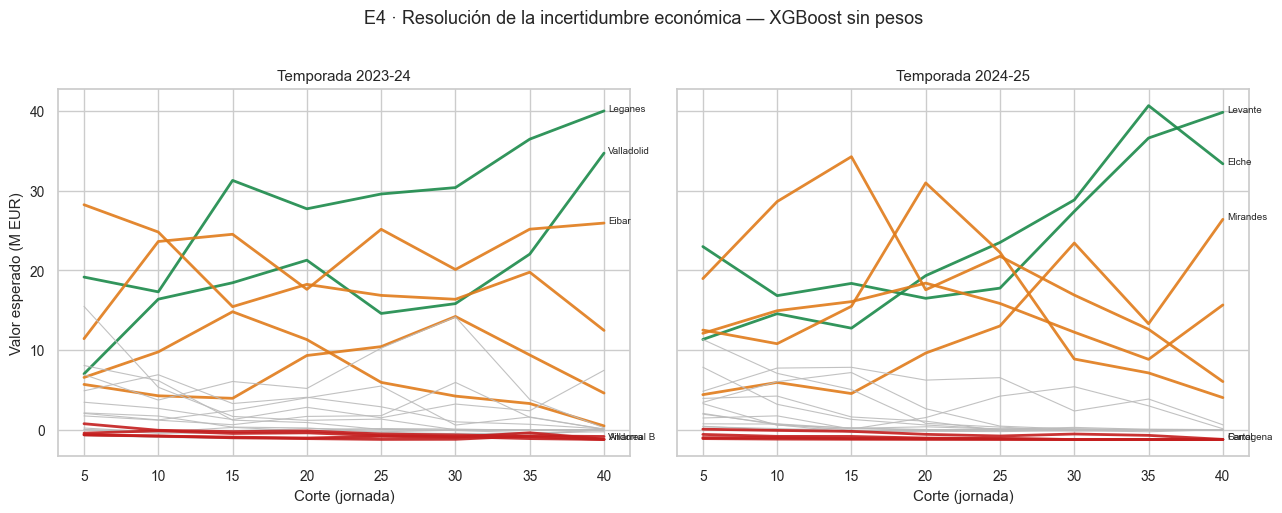

,season,j5,j10,j15,j20,j25,j30,j35,j40
0,2023-24,7.4,8.0,9.2,8.4,8.8,8.9,10.5,12.1
1,2024-25,6.7,7.6,8.9,9.1,8.9,9.8,11.6,12.0


In [ ]:
MODELO_E4 = "XGBoost sin pesos"
fig, axes = plt.subplots(1, 2, figsize=(13, 5), sharey=True)
dispersion = []
for ax, (season, etiqueta) in zip(axes, [(2023, "2023-24"), (2024, "2024-25")]):
    cortes = eco.cargar_cortes(MODELO_E4, season)
    evs = pd.DataFrame({j: eco.valor_esperado_equipo(c) for j, c in cortes.items()}) / 1e6
    final = cortes[max(cortes)].pos_real
    for eq in evs.index:
        pr = final[eq]
        color = "#1b8a4a" if pr <= 2 else "#e07b1a" if pr <= 6 else"#c41e1e" if pr >= 19 else "#bbbbbb"
        lw = 2 if (pr <= 6 or pr >= 19) else 0.8
        ax.plot(evs.columns, evs.loc[eq], color=color, lw=lw, alpha=0.9)
        if pr <= 3 or pr >= 21:
            ax.annotate(eq, (evs.columns[-1], evs.loc[eq].iloc[-1]),
                        fontsize=7, xytext=(3, 0), textcoords="offset points")
    ax.set_title(f"Temporada {etiqueta}"); ax.set_xlabel("Corte (jornada)")
    dispersion.append({"season": etiqueta,
                       **{f"j{j}": float(evs[j].std()) for j in evs.columns}})
axes[0].set_ylabel("Valor esperado (M EUR)")
plt.suptitle(f"E4 · Resolución de la incertidumbre económica — {MODELO_E4}", y=1.02)
plt.tight_layout(); plt.savefig(FIGURES / "f07_embudo_economico.png", dpi=150,
                                bbox_inches="tight"); plt.show()
pd.DataFrame(dispersion).round(1).to_csv(TABLES / "t07_dispersion_economica.csv", index=False)
pd.DataFrame(dispersion).round(1)

## 8. ¿Quién rinde por encima de su presupuesto?

Valor de plantilla vs puntos finales en las 15 temporadas completas; los residuos
identifican a los equipos que rompen la lógica del presupuesto. Después se comprueba si
los modelos anticipan esas sorpresas o solo siguen el dinero (correlación entre el valor
de plantilla y la P(ascenso) asignada en el test).

r = 0.455, R² = 0.207 | pendiente = 0.457 pts/M EUR


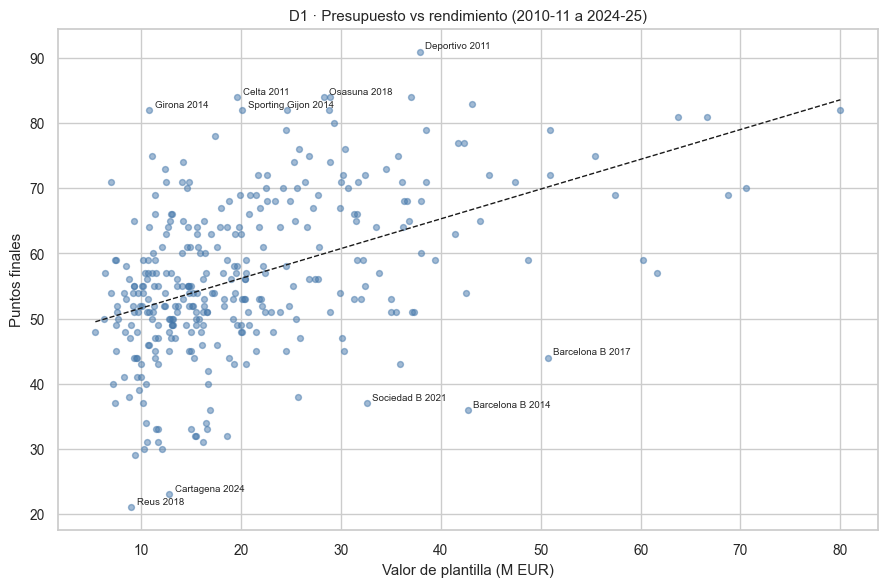

,season,equipo,puntos,mv,residuo
93,2014,Girona,82,10.8,30.0
27,2011,Celta,84,19.6,28.0
29,2011,Deportivo,91,37.9,26.6
106,2014,Sporting Gijon,82,20.1,25.8
191,2018,Osasuna,84,28.2,24.1
91,2014,Barcelona B,36,42.7,-30.6
194,2018,Reus,21,9.0,-30.2
312,2024,Cartagena,23,12.8,-29.9
157,2017,Barcelona B,44,50.7,-26.2
259,2021,Sociedad B,37,32.6,-24.9


In [12]:
mc_all = pd.read_parquet("data/interim/matches_clean.parquet")
mc_all = mc_all[mc_all.season < 2025]
pts = []
for (s, eq), g in mc_all.melt(
        id_vars=["season","ftr"], value_vars=["home_team","away_team"],
        var_name="rol", value_name="equipo").groupby(["season","equipo"]):
    p = ((g.rol == "home_team") & (g.ftr == "H")) * 3 + \
        ((g.rol == "away_team") & (g.ftr == "A")) * 3 + (g.ftr == "D") * 1
    pts.append({"season": s, "equipo": eq, "puntos": int(p.sum())})
pts = pd.DataFrame(pts)

mv = pd.concat([
    df_full[["season","home_team","home_mv"]].rename(columns={"home_team":"equipo","home_mv":"mv"}),
    df_full[["season","away_team","away_mv"]].rename(columns={"away_team":"equipo","away_mv":"mv"}),
]).dropna().groupby(["season","equipo"], as_index=False).mv.first()

d1 = pts.merge(mv, on=["season","equipo"])
from scipy.stats import pearsonr
r, _ = pearsonr(d1.mv, d1.puntos)
a, b = np.polyfit(d1.mv, d1.puntos, 1)
d1["residuo"] = d1.puntos - (a * d1.mv + b)
print(f"r = {r:.3f}, R² = {r**2:.3f} | pendiente = {a:.3f} pts/M EUR")

fig, ax = plt.subplots(figsize=(9, 6))
ax.scatter(d1.mv, d1.puntos, s=18, alpha=0.5, color="#4477aa")
xs = np.linspace(d1.mv.min(), d1.mv.max(), 50); ax.plot(xs, a*xs+b, "k--", lw=1)
ext = pd.concat([d1.nlargest(5, "residuo"), d1.nsmallest(5, "residuo")])
for _, row in ext.iterrows():
    ax.annotate(f"{row.equipo} {row.season}", (row.mv, row.puntos), fontsize=7,
                xytext=(4, 2), textcoords="offset points")
ax.set_xlabel("Valor de plantilla (M EUR)"); ax.set_ylabel("Puntos finales")
ax.set_title("D1 · Presupuesto vs rendimiento (2010-11 a 2024-25)")
plt.tight_layout(); plt.savefig(FIGURES / "f08_presupuesto_rendimiento.png", dpi=150); plt.show()
ext.round(1).to_csv(TABLES / "t08_sorpresas.csv", index=False)
ext.round(1)

In [ ]:
filas = []
for m in MODELOS_TODOS:
    cors = []
    for season in (2023, 2024):
        mc = pd.read_csv(MC_FULL / f"montecarlo_{slug_de(m)}_t{season}.csv")
        mvs = mv[mv.season == season].set_index("equipo").mv
        comun = mc.set_index("equipo").join(mvs, how="inner").dropna(subset=["mv"])
        cors.append(pearsonr(comun.mv, comun["P(asc_total)"])[0])
    filas.append({"modelo": m, "corr_mv_Pasc_2023": cors[0], "corr_mv_Pasc_2024": cors[1]})
tabla_d1 = pd.DataFrame(filas).sort_values("corr_mv_Pasc_2023", ascending=False)
tabla_d1.to_csv(TABLES / "t08b_correlacion_dinero.csv", index=False)
tabla_d1.round(3)

,modelo,corr_mv_Pasc_2023,corr_mv_Pasc_2024
8,MLP,0.811,0.815
9,Doble Poisson,0.811,0.879
0,LogReg sin pesos,0.773,0.859
1,LogReg balanced,0.771,0.857
7,LightGBM balanced,0.703,0.829
6,LightGBM sin pesos,0.677,0.828
4,XGBoost sin pesos,0.665,0.806
5,XGBoost balanced,0.658,0.789
3,Random Forest balanced,0.652,0.811
2,Random Forest sin pesos,0.636,0.790


## 9. Momentum vs valor: ablation por familias

Se reentrenan las configuraciones finales de XGBoost sin pesos y LogReg sin pesos
quitando cada familia de variables. La caída de rendimiento mide cuánto aporta cada una.
La variante «sin familia E» es además la **comparación limpia contra el mercado**
(modelos sin información de cuotas).

In [ ]:
from sklearn.utils.class_weight import compute_sample_weight

FAMILIAS = {
    "A forma":   [c for c in FEATS if any(k in c for k in ("_ppg_","_gf_","_gc_"))],
    "B clasif.": [c for c in FEATS if c.endswith(("_pos_pre","_pts_pre","_gd_pre"))],
    "C valor":   [c for c in FEATS if c.endswith("_mv")],
    "D elo":     [c for c in FEATS if "elo" in c],
    "E mercado": ["prob_h", "match_uncertainty"],
    "F descanso":[c for c in FEATS if "rest_days" in c],
}
assert sum(map(len, FAMILIAS.values())) == len(FEATS)

te = df_full[df_full.split == "test"].dropna(subset=FEATS)
y_te_str = te["ftr"].values
y_tr_map = {"LogReg sin pesos": y_tr, "XGBoost sin pesos": y_tr_enc,
            "XGBoost balanced": y_tr_enc}

SW_MAP = {"XGBoost balanced": compute_sample_weight("balanced", y_tr_enc)}

def refit_eval(modelo_nombre, fichero, escala, cols):
    mdl = clone(joblib.load(Path("models") / fichero))
    Xtr, Xte = X_tr[cols], te[cols]
    if escala:
        sc = StandardScaler().fit(Xtr.astype(float))
        Xtr, Xte = sc.transform(Xtr.astype(float)), sc.transform(Xte.astype(float))
    else:
        Xtr, Xte = Xtr.values, Xte.values
    mdl.fit(Xtr, y_tr_map[modelo_nombre], sample_weight=SW_MAP.get(modelo_nombre))
    Pte = mdl.predict_proba(Xte)
    return {"log_loss": log_loss(y_te_str, Pte, labels=LABELS),
            "rps": rps(y_te_str, Pte)}

filas = []
for nombre, fichero, escala in [("XGBoost sin pesos", "xgboost_simple.pkl", False),
                                 ("LogReg sin pesos", "logistic_regression_simple.pkl", True),
                                 ("XGBoost balanced", "xgboost_balanced.pkl", False)]:
    base = refit_eval(nombre, fichero, escala, FEATS)
    filas.append({"modelo": nombre, "config": "todas las familias", **base,
                  "d_logloss": 0.0, "d_rps": 0.0})
    for fam, cols_fam in FAMILIAS.items():
        resto = [c for c in FEATS if c not in cols_fam]
        r = refit_eval(nombre, fichero, escala, resto)
        filas.append({"modelo": nombre, "config": f"sin {fam}", **r,
                      "d_logloss": r["log_loss"] - base["log_loss"],
                      "d_rps": r["rps"] - base["rps"]})
        print(f"{nombre:20s} sin {fam:11s} d_ll={r['log_loss']-base['log_loss']:+.4f}")
tabla_ablation = pd.DataFrame(filas)
tabla_ablation.to_csv(TABLES / "t09_ablation.csv", index=False)
tabla_ablation.round(4)

XGBoost sin pesos    sin A forma     d_ll=+0.0012
XGBoost sin pesos    sin B clasif.   d_ll=-0.0012


XGBoost sin pesos    sin C valor     d_ll=-0.0001
XGBoost sin pesos    sin D elo       d_ll=+0.0003


XGBoost sin pesos    sin E mercado   d_ll=+0.0068


XGBoost sin pesos    sin F descanso  d_ll=+0.0001
LogReg sin pesos     sin A forma     d_ll=+0.0022
LogReg sin pesos     sin B clasif.   d_ll=-0.0005
LogReg sin pesos     sin C valor     d_ll=+0.0011
LogReg sin pesos     sin D elo       d_ll=-0.0000
LogReg sin pesos     sin E mercado   d_ll=+0.0075
LogReg sin pesos     sin F descanso  d_ll=+0.0004


XGBoost balanced     sin A forma     d_ll=+0.0030


...

XGBoost balanced     sin C valor     d_ll=+0.0051


XGBoost balanced     sin D elo       d_ll=+0.0046


XGBoost balanced     sin E mercado   d_ll=+0.0060


XGBoost balanced     sin F descanso  d_ll=+0.0001


,modelo,config,log_loss,rps,d_logloss,d_rps
0,XGBoost sin pesos,todas las familias,1.0296,0.2067,0.0000,0.0000
1,XGBoost sin pesos,sin A forma,1.0308,0.2066,0.0012,-0.0001
2,XGBoost sin pesos,sin B clasif.,1.0284,0.2064,-0.0012,-0.0002
3,XGBoost sin pesos,sin C valor,1.0295,0.2068,-0.0001,0.0002
4,XGBoost sin pesos,sin D elo,1.0299,0.2064,0.0003,-0.0002
5,XGBoost sin pesos,sin E mercado,1.0364,0.2088,0.0068,0.0022
6,XGBoost sin pesos,sin F descanso,1.0296,0.2065,0.0001,-0.0001
7,LogReg sin pesos,todas las familias,1.0312,0.2071,0.0000,0.0000
8,LogReg sin pesos,sin A forma,1.0334,0.2074,0.0022,0.0003
9,LogReg sin pesos,sin B clasif.,1.0306,0.2069,-0.0005,-0.0002


## 10. Temporadas al detalle

Trayectoria de las probabilidades de ascenso y descenso de los protagonistas, jornada a
jornada (Montecarlo a cortes). Solo se narran las temporadas del conjunto de prueba: los
modelos no las han visto durante el entrenamiento.

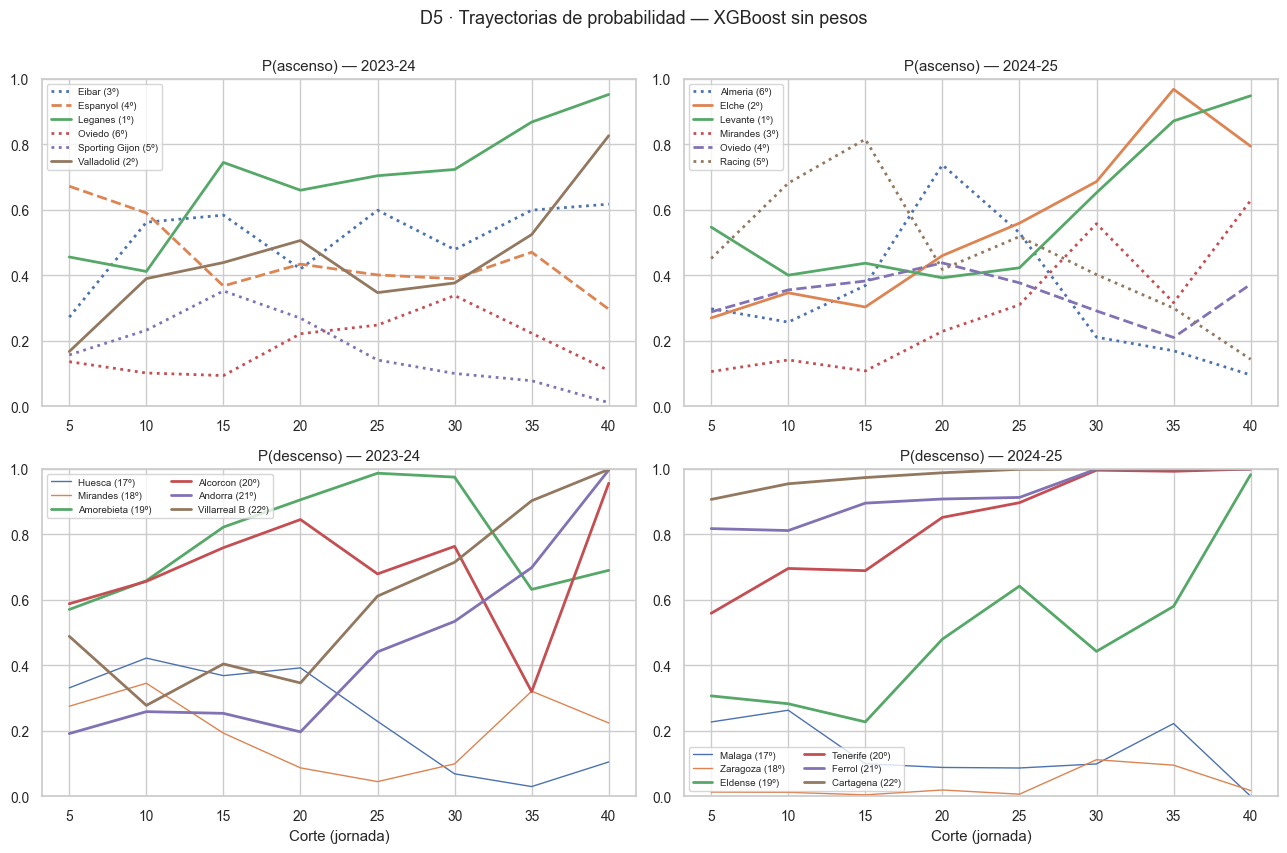

In [15]:
MODELO_D5 = "XGBoost sin pesos"
fig, axes = plt.subplots(2, 2, figsize=(13, 8.5))
for col, (season, etiqueta, po) in enumerate([(2023, "2023-24", "Espanyol"),
                                               (2024, "2024-25", "Oviedo")]):
    cortes = eco.cargar_cortes(MODELO_D5, season)
    final = cortes[max(cortes)].pos_real
    asc = pd.DataFrame({j: c["P(asc_total)"] for j, c in cortes.items()})
    des = pd.DataFrame({j: c["P(descenso)"] for j, c in cortes.items()})
    ax = axes[0][col]
    for eq in final[final <= 6].index.union([po]):
        estilo = "-" if final[eq] <= 2 else ("--" if eq == po else ":")
        ax.plot(asc.columns, asc.loc[eq], estilo, lw=2, label=f"{eq} ({int(final[eq])}º)")
    ax.set_title(f"P(ascenso) — {etiqueta}"); ax.legend(fontsize=7); ax.set_ylim(0, 1)
    ax = axes[1][col]
    for eq in final[final >= 17].index:
        lw = 2 if final[eq] >= 19 else 1
        ax.plot(des.columns, des.loc[eq], lw=lw, label=f"{eq} ({int(final[eq])}º)")
    ax.set_title(f"P(descenso) — {etiqueta}"); ax.legend(fontsize=7, ncol=2); ax.set_ylim(0, 1)
    ax.set_xlabel("Corte (jornada)")
plt.suptitle(f"D5 · Trayectorias de probabilidad — {MODELO_D5}", y=1.0)
plt.tight_layout(); plt.savefig(FIGURES / "f10_temporadas_detalle.png", dpi=150,
                                bbox_inches="tight"); plt.show()

## 11. El test del recién ascendido

Equipos del test sin presencia en Segunda la temporada anterior. Los que bajan de Primera
llegan con histórico de Elo/forma de élite; los que suben de Primera Federación entran sin
historia comparable en el dataset. Se mide el error en los partidos que los involucran.

In [16]:
DESCENDIDOS_PRIMERA = {2023: {"Espanyol", "Valladolid", "Elche"},
                       2024: {"Almeria", "Granada", "Cadiz"}}
equipos_por_season = mc_all.groupby("season").home_team.unique().to_dict()
recien = {}
for s in (2023, 2024):
    nuevos = set(equipos_por_season[s]) - set(equipos_por_season[s - 1])
    desc = {e for e in nuevos if e in DESCENDIDOS_PRIMERA[s]}
    rfef = nuevos - desc
    recien[s] = {"de Primera": desc, "de Primera Federación": rfef}
    print(f"{s}: bajan {sorted(desc)} | suben {sorted(rfef)}")

def grupo(r):
    n = recien[int(r.season)]
    eqs = {r.home_team, r.away_team}
    if eqs & n["de Primera Federación"]: return "con recién ascendido (RFEF)"
    if eqs & n["de Primera"]:            return "con recién descendido (1ª)"
    return "sin recién llegados"
test["grupo_d6"] = test.apply(grupo, axis=1)

filas = []
for g, sub in test.groupby("grupo_d6"):
    fila = {"grupo": g, "n": len(sub)}
    for m in ["XGBoost sin pesos", "LogReg sin pesos", "Doble Poisson"]:
        fila[m] = log_loss(sub.ftr, P(sub, m), labels=LABELS)
    fila["Mercado"] = log_loss(sub.ftr, P_mercado(sub), labels=LABELS)
    filas.append(fila)
tabla_d6 = pd.DataFrame(filas)
tabla_d6.to_csv(TABLES / "t11_recien_ascendidos.csv", index=False)
tabla_d6.round(4)

2023: bajan ['Elche', 'Espanyol', 'Valladolid'] | suben ['Alcorcon', 'Amorebieta', 'Eldense', 'Ferrol']
2024: bajan ['Almeria', 'Cadiz', 'Granada'] | suben ['Castellon', 'Cordoba', 'Deportivo', 'Malaga']


,grupo,n,XGBoost sin pesos,LogReg sin pesos,Doble Poisson,Mercado
0,con recién ascendido (RFEF),304,1.0457,1.0516,1.0530,1.0525
1,con recién descendido (1ª),186,1.0039,1.0045,1.0098,0.9948
2,sin recién llegados,411,1.0292,1.0281,1.0308,1.0275


## 12. Índice de salidas generadas

In [17]:
print("TABLAS (reports/tables/):")
for f in sorted(TABLES.glob("t*.csv")): print("  ", f.name)
print("FIGURAS (reports/figures/):")
for f in sorted(FIGURES.glob("f*.png")): print("  ", f.name)

TABLAS (reports/tables/):
   t01_tabla_maestra.csv
   t02_calibracion.csv
   t03_tests_estadisticos.csv
   t04_situaciones.csv
   t05_error_economico.csv
   t06_pee.csv
   t06b_partidos_mas_dinero.csv
   t07_dispersion_economica.csv
   t08_sorpresas.csv
   t08b_correlacion_dinero.csv
   t09_ablation.csv
   t11_recien_ascendidos.csv
   t13_shap_importancia.csv
FIGURAS (reports/figures/):
   f02_reliability_H.png
   f07_embudo_economico.png
   f08_presupuesto_rendimiento.png
   f10_temporadas_detalle.png
   f13_shap_beeswarm_H.png
   f13_shap_importancia.png
